## Introduction

In this script, we do some basic visualisation.

## Importing the Python libraries

In [20]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

In [21]:
parent_dir = Path.cwd().parent
parent_dir

WindowsPath('c:/Ellen/personal/projects/geospatial/lst_bang_chennai/lstroad')

In [22]:
file_path_bangalore = parent_dir / "data" / "processed"/ "bang_fix_mapshaper.shp"

## Dissolve the wards

In [23]:
gdf_bangalore = gpd.read_file(file_path_bangalore)

In [24]:
print(f'There are  {gdf_bangalore.shape[0]} wards in Bangalore')
print(f'There are  {gdf_bangalore.shape[1]} columns in the dataset for Bangalore')

There are  369 wards in Bangalore
There are  4 columns in the dataset for Bangalore


<Axes: >

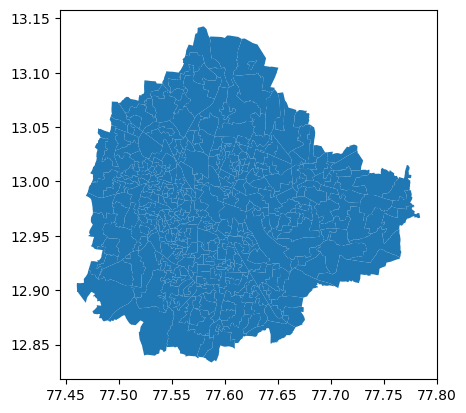

In [25]:
gdf_bangalore.plot()

In [26]:
gdf_bangalore.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [27]:
gdf_bangalore.columns

Index(['ward_id', 'ward_name', 'Corporatio', 'geometry'], dtype='object')

In [28]:
gdf_bangalore['Corporatio'].value_counts()

Corporatio
West       112
North       72
South       72
Central     63
East        50
Name: count, dtype: int64

In [29]:
gdf_bangalore_dissolved = gdf_bangalore.dissolve()

<Axes: >

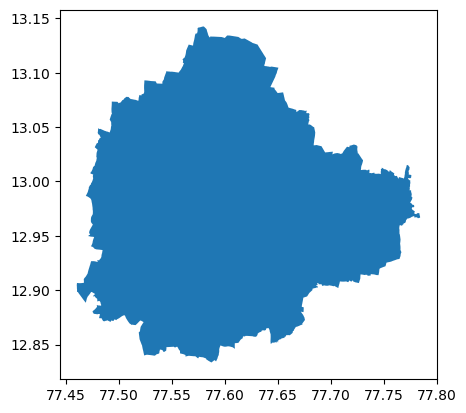

In [30]:
gdf_bangalore_dissolved.plot()

Save this shape file for later use (e.g. when extracting the road network).

In [31]:
dissolved_bang_path = parent_dir / "data" / "processed"/ "bangalore_dissolved.shp"
gdf_bangalore_dissolved.to_file(dissolved_bang_path)

## Visualisation

In [32]:
# This reprojection is purely done for visualisation sake
# and position the shape of the labels
gdf_reproj = gdf_bangalore.to_crs(epsg=3857)

In [33]:
# Path where to save the image:
path_figure = parent_dir / "images" / "bangalore_wards.png"

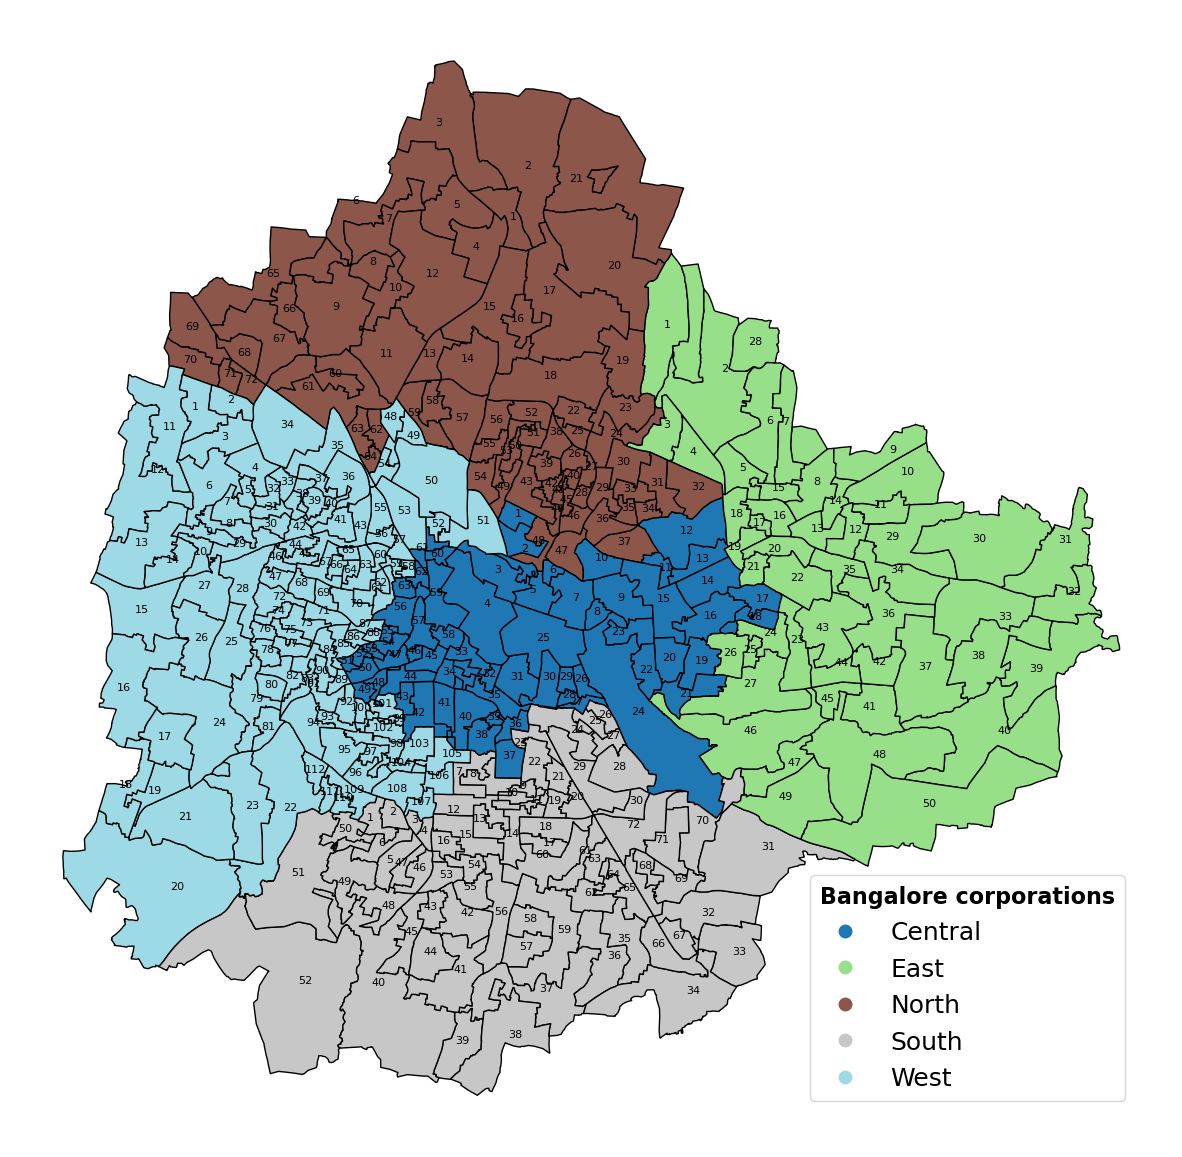

In [34]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15,15)


gdf_reproj["label_point"] = gdf_reproj.geometry.representative_point()

legend_kwds={
    'bbox_to_anchor':(.97, .25),
    'fontsize':18,
    'frameon':True}

gdf_reproj.plot(
    ax=ax, 
    column = 'Corporatio',
    categorical=True,
    cmap="tab20",
    linewidth=1,
    edgecolor='black',
    legend_kwds= legend_kwds,
    legend = True)

legend = ax.get_legend()

# Stackoverflow: 
# https://stackoverflow.com/questions/15637961/matplotlib-alignment-of-legend-title
legend.set_title("Bangalore corporations", prop={"size": 16, "weight": "bold"})
legend._legend_box.align = "left"
legend.get_title().set_ha("left")
legend.prop.set_size(14)


gdf_reproj["label_point"] = gdf_reproj.geometry.representative_point()


for _, row in gdf_reproj.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row["ward_id"],
        fontsize=8,
        ha="center",
    )

ax.set_axis_off()

plt.savefig(path_figure, dpi=300, bbox_inches='tight')

plt.show()
